# Use time-travel
## Overview

LangGraph supports time travel through checkpoints:

* Replay: Retry from a prior checkpoint.
* Fork: Branch from a prior checkpoint with modified state to explore an alternative path.

Both work by resuming from a prior checkpoint. Nodes before the checkpoint are not re-executed (results are already saved). Nodes after the checkpoint re-execute, including any LLM calls, API requests, and `interrupts` (which may produce different results).

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

## Replay

Invoke the graph with a prior checkpoint’s config to replay from that point.

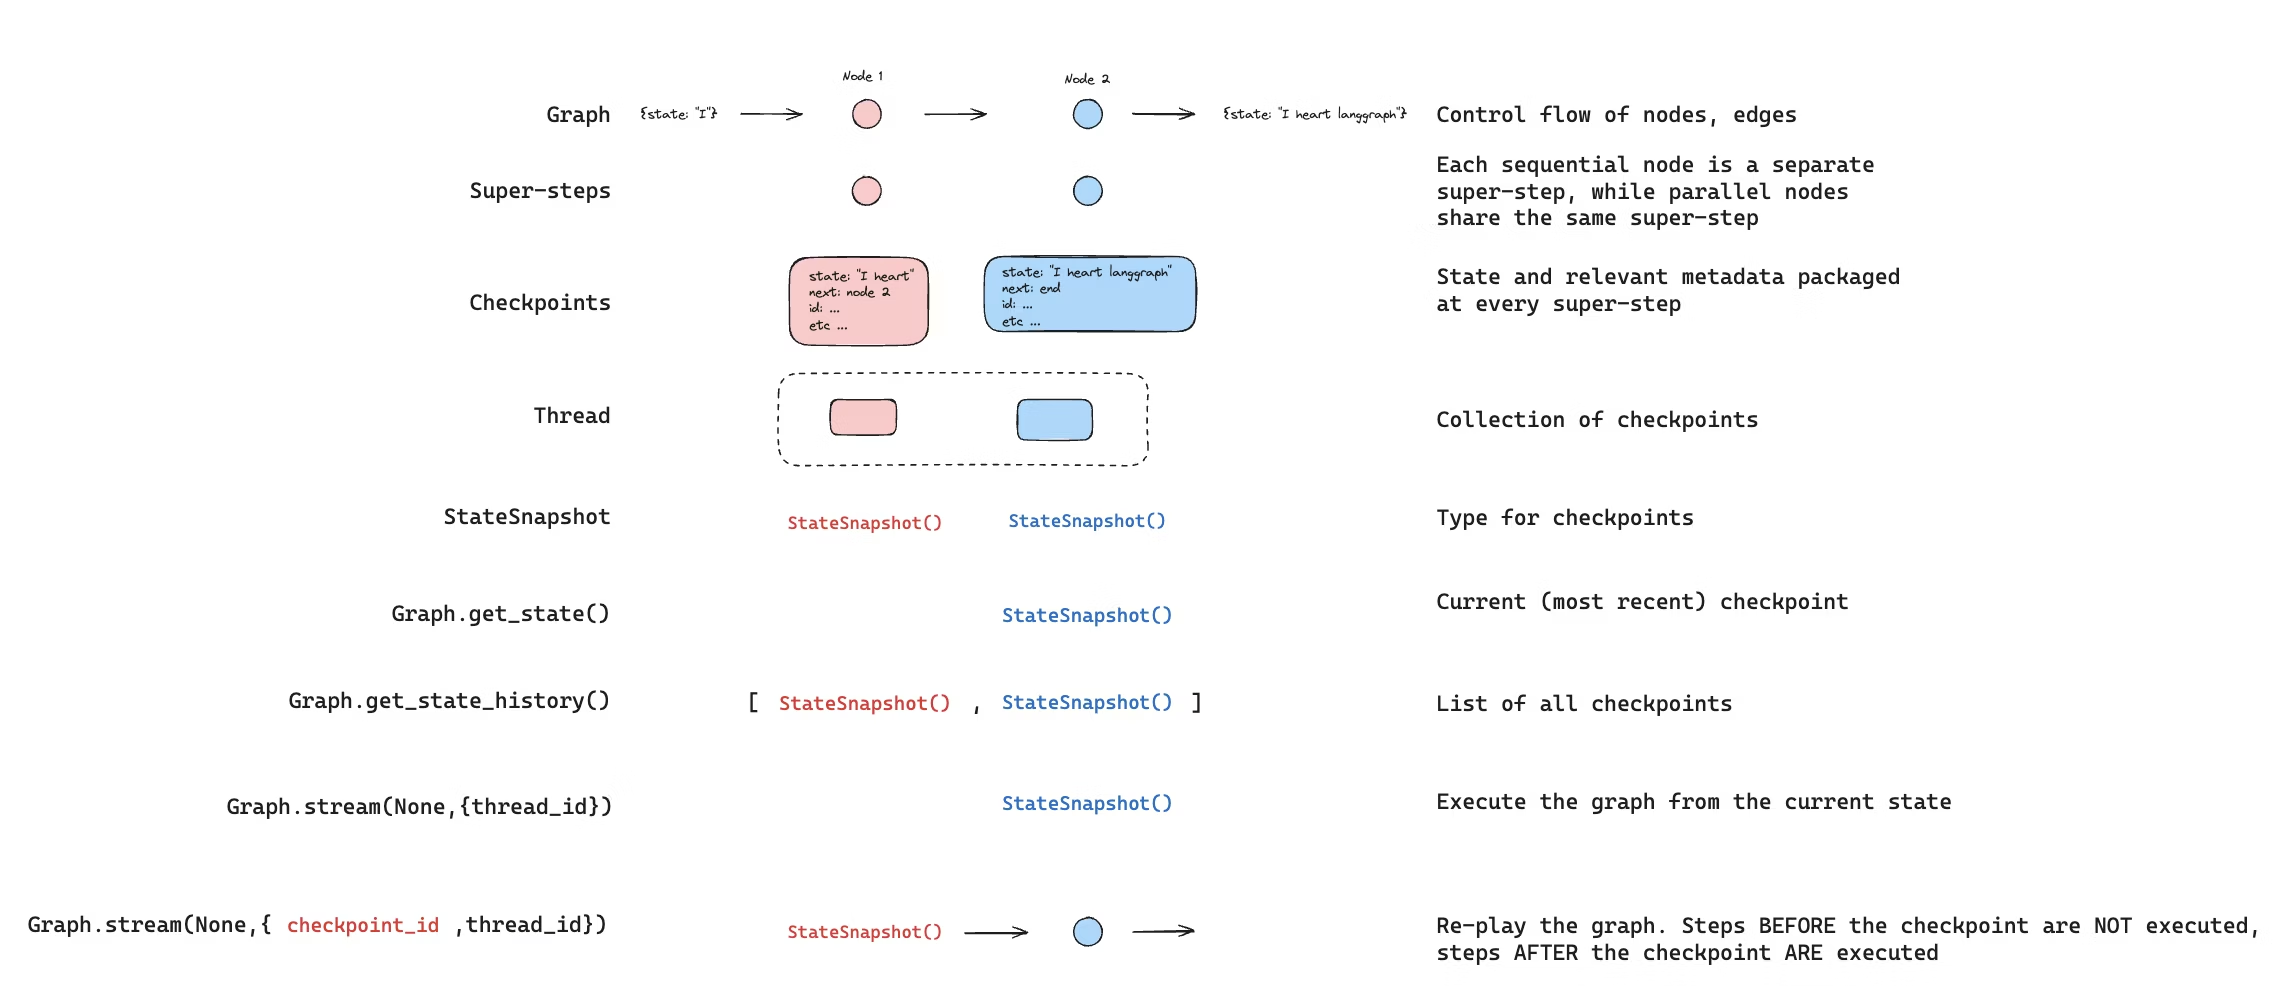

Use `get_state_history` to find the checkpoint you want to replay from, then call `invoke` with that checkpoint’s config:

In [2]:
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver
from typing_extensions import TypedDict, NotRequired
import uuid


class State(TypedDict):
    topic: NotRequired[str]
    joke: NotRequired[str]


def generate_topic(state: State):
    return {"topic": "socks in the dryer"}


def write_joke(state: State):
    return {"joke": f"Why do {state['topic']} disappear? They elope!"}


checkpointer = InMemorySaver()
graph = (
    StateGraph(State)
    .add_node("generate_topic", generate_topic)
    .add_node("write_joke", write_joke)
    .add_edge(START, "generate_topic")
    .add_edge("generate_topic", "write_joke")
    .compile(checkpointer=checkpointer)
)

# Step 1: Run the graph
config = {"configurable": {"thread_id": str(uuid.uuid4())}}
result = graph.invoke({}, config)

# Step 2: Find a checkpoint to replay from
history = list(graph.get_state_history(config))
# History is in reverse chronological order
for state in history:
    print(
        f"next={state.next}, checkpoint_id={state.config['configurable']['checkpoint_id']}"
    )

# Step 3: Replay from a specific checkpoint
# Find the checkpoint before write_joke
before_joke = next(s for s in history if s.next == ("write_joke",))
replay_result = graph.invoke(None, before_joke.config)
# write_joke re-executes (runs again), generate_topic does not

next=(), checkpoint_id=1f121e1e-8a06-68de-8002-afd09a05be26
next=('write_joke',), checkpoint_id=1f121e1e-8a06-68dd-8001-7942ba0ef17b
next=('generate_topic',), checkpoint_id=1f121e1e-8a03-6d93-8000-c07c1c9fc637
next=('__start__',), checkpoint_id=1f121e1e-8a02-6a17-bfff-ccd6dc8334b1


## Fork

Fork creates a new branch from a past checkpoint with modified state. Call `update_state` on a prior checkpoint to create the fork, then `invoke` with `None` to continue execution.

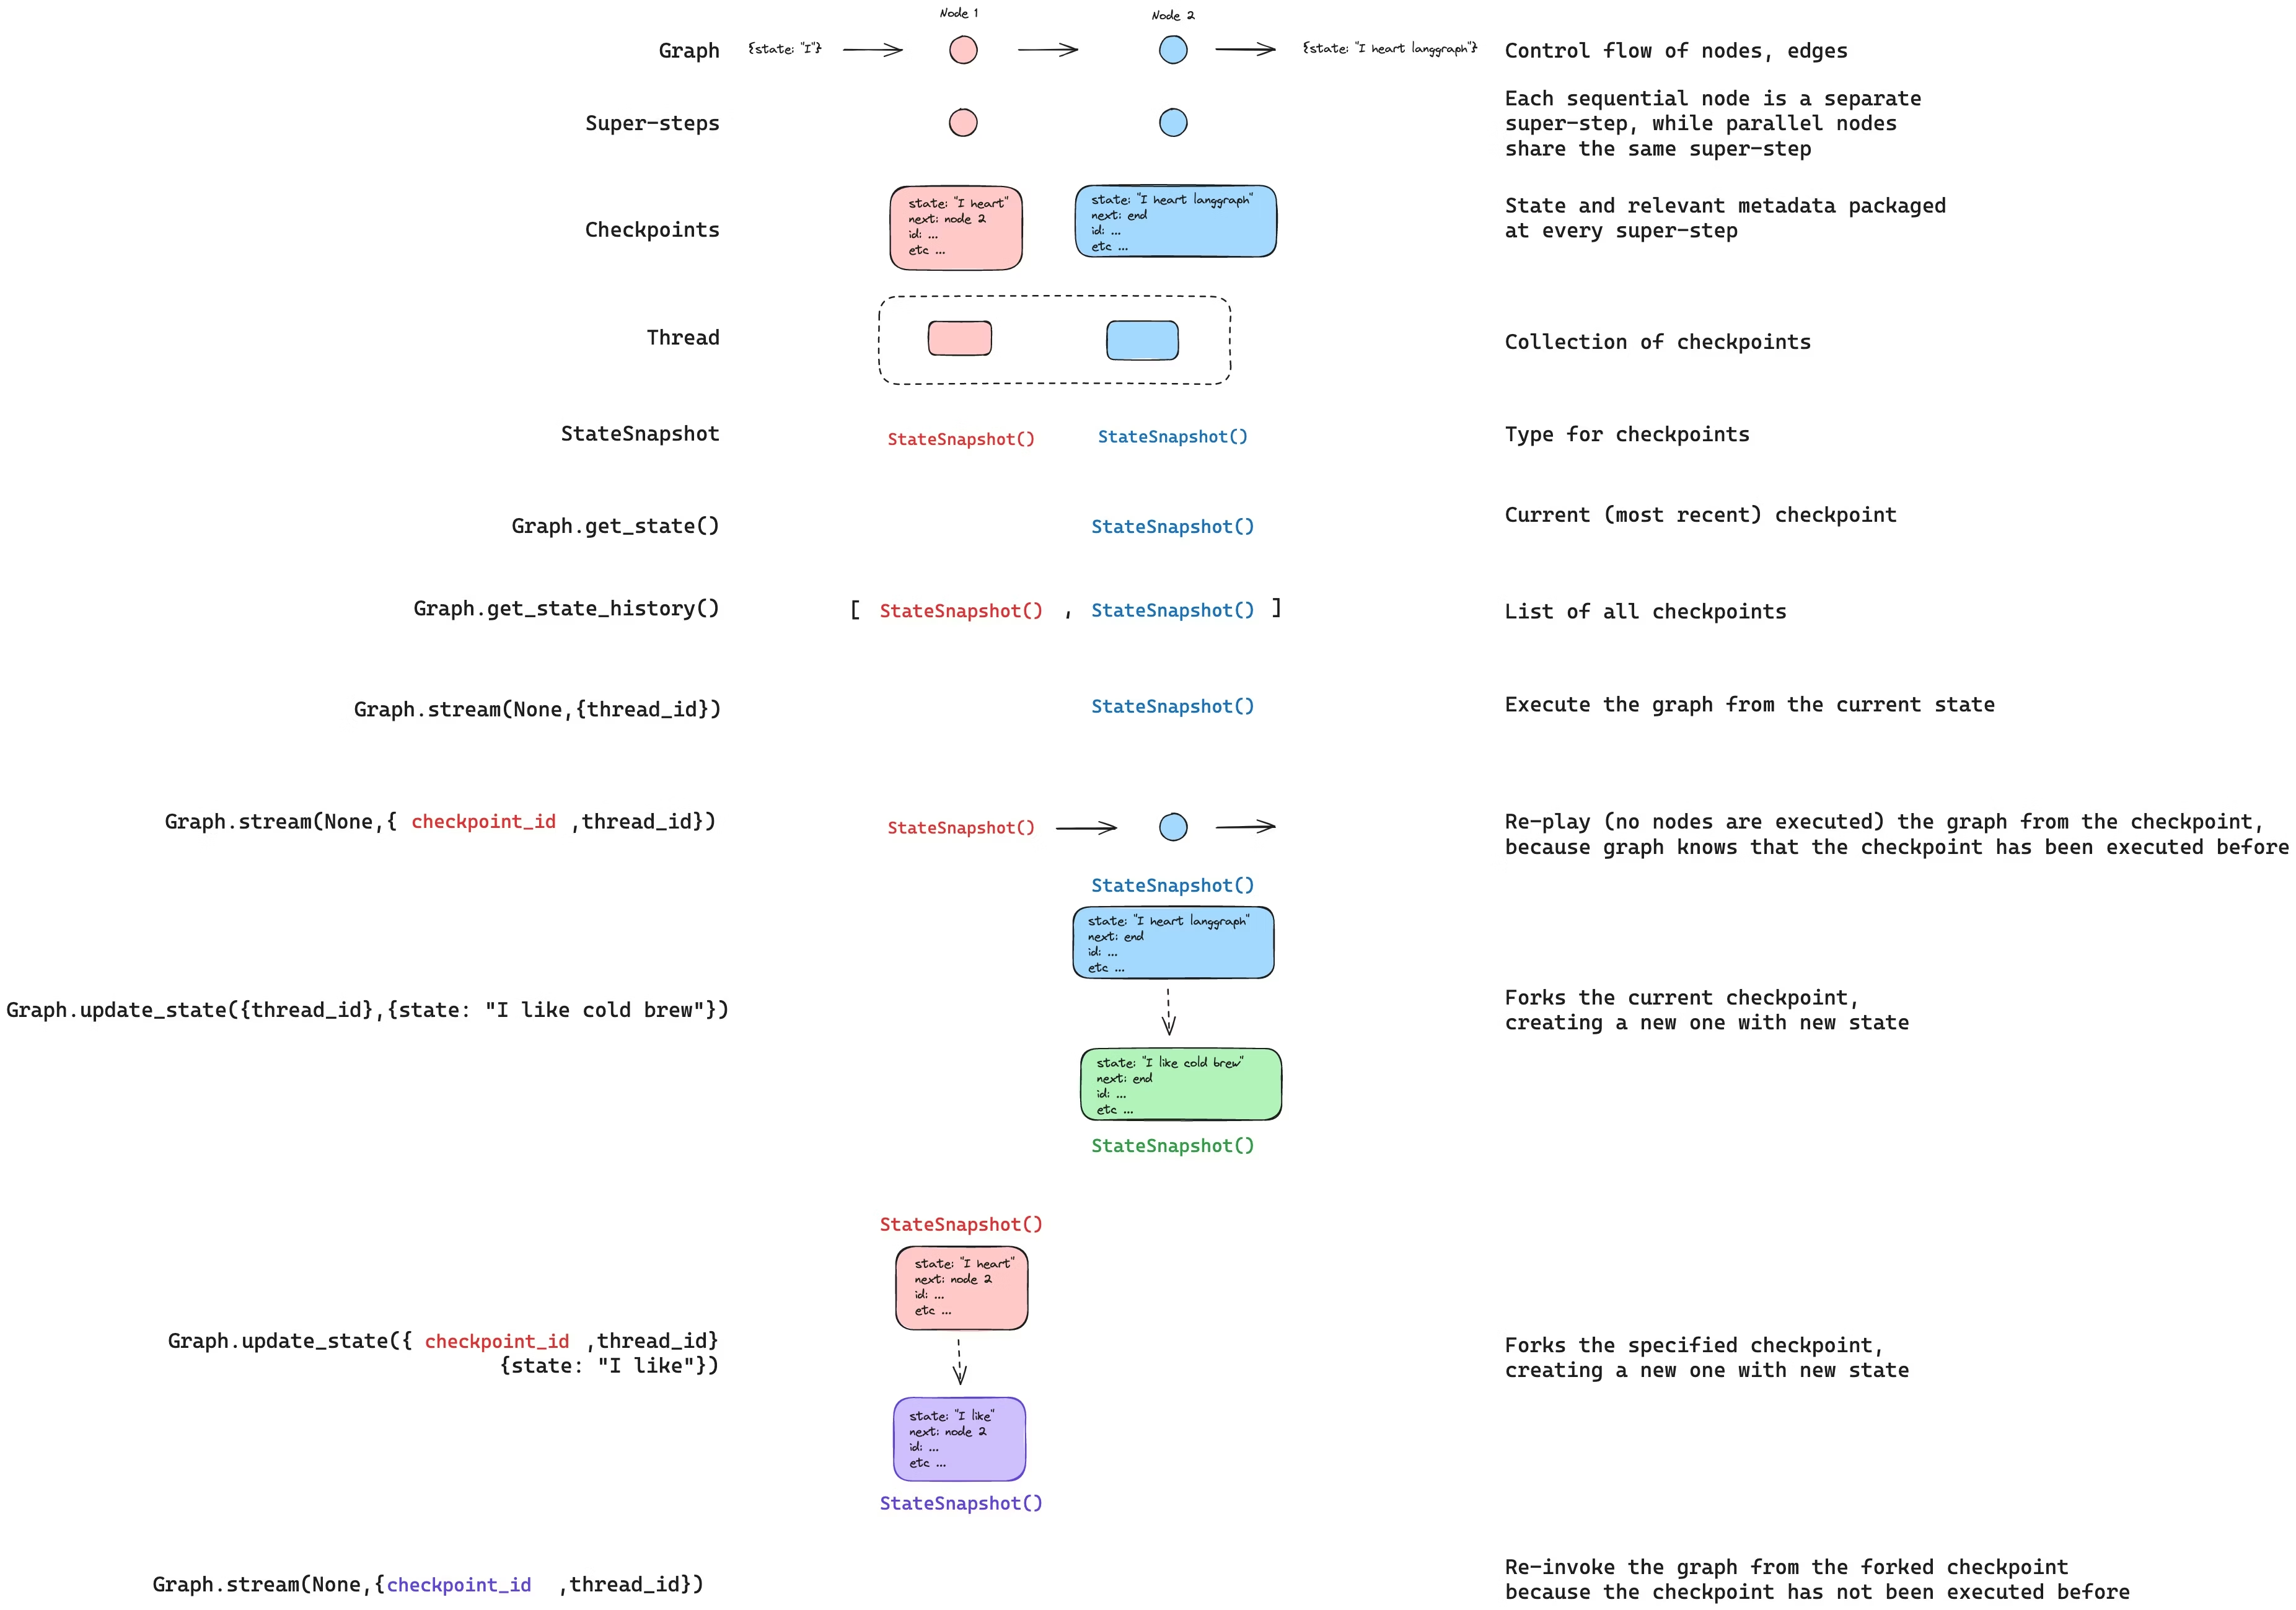

`update_state` does not roll back a thread. It creates a new checkpoint that branches from the specified point. The original execution history remains intact.

In [3]:
# Find checkpoint before write_joke
history = list(graph.get_state_history(config))
before_joke = next(s for s in history if s.next == ("write_joke",))

# Fork: update state to change the topic
fork_config = graph.update_state(
    before_joke.config,
    values={"topic": "chickens"},
)

# Resume from the fork — write_joke re-executes with the new topic
fork_result = graph.invoke(None, fork_config)
print(fork_result["joke"])  # A joke about chickens, not socks

Why do chickens disappear? They elope!


### From a specific node

When you call update_state, values are applied using the specified node’s writers (including reducers). The checkpoint records that node as having produced the update, and execution resumes from that node’s successors.

By default, LangGraph infers as_node from the checkpoint’s version history. When forking from a specific checkpoint, this inference is almost always correct.

Specify as_node explicitly when:

* **Parallel branches**: Multiple nodes updated state in the same step, and LangGraph can’t determine which was last (InvalidUpdateError).
* **No execution history**: Setting up state on a fresh thread (common in testing).
* **Skipping nodes**: Set as_node to a later node to make the graph think that node already ran.

In [5]:
# graph: generate_topic -> write_joke

# Treat this update as if generate_topic produced it.
# Execution resumes at write_joke (the successor of generate_topic).
fork_config = graph.update_state(
    before_joke.config,
    values={"topic": "chickens"},
    as_node="generate_topic",
)

# Resume from the fork — write_joke re-executes with the new topic
fork_result = graph.invoke(None, fork_config)
print(fork_result["joke"])  # A joke about chickens, not socks

Why do chickens disappear? They elope!


### Interrupts

If your graph uses `interrupt` for `human-in-the-loop` workflows, interrupts are always re-triggered during time travel. The node containing the `interrupt` re-executes, and `interrupt`() pauses for a new `Command`(resume=...).

In [13]:
from langgraph.types import interrupt, Command


class State(TypedDict):
    value: list[str]


def ask_human(state: State):
    answer = interrupt("What is your name?")
    return {"value": [f"Hello, {answer}!"]}


def final_step(state: State):
    return {"value": ["Done"] + state["value"]}


graph = (
    StateGraph(State)
    .add_node("ask_human", ask_human)
    .add_node("final_step", final_step)
    .add_edge(START, "ask_human")
    .add_edge("ask_human", "final_step")
    .compile(checkpointer=InMemorySaver())
)

config = {"configurable": {"thread_id": "1"}}

# First run: hits interrupt
graph.invoke({"value": []}, config)


{'value': [],
 '__interrupt__': [Interrupt(value='What is your name?', id='33b79ca49072e6c67ff1caf601b52b9c')]}

In [16]:
# Resume with answer
graph.invoke(Command(resume="Alice"), config)

# Replay from before ask_human
history = list(graph.get_state_history(config))
before_ask = [s for s in history if s.next == ("ask_human",)][-1]

replay_result = graph.invoke(None, before_ask.config)
# Pauses at interrupt — waiting for new Command(resume=...)

# Fork from before ask_human
fork_config = graph.update_state(before_ask.config, {"value": ["forked"]})
fork_result = graph.invoke(None, fork_config)
# Pauses at interrupt — waiting for new Command(resume=...)

# Resume the forked interrupt with a different answer
graph.invoke(Command(resume="Bob"), fork_config)
# Result: {"value": ["forked", "Hello, Bob!", "Done"]}

{'value': ['Done', 'Hello, Bob!']}

## Multiple interrupts

If your graph collects input at several points (for example, a multi-step form), you can fork from between the interrupts to change a later answer without re-asking earlier questions.

In [17]:
def ask_name(state):
    name = interrupt("What is your name?")
    return {"value": [f"name:{name}"]}


def ask_age(state):
    age = interrupt("How old are you?")
    return {"value": [f"age:{age}"]}


# Graph: ask_name -> ask_age -> final
# After completing both interrupts:

# Fork from BETWEEN the two interrupts (after ask_name, before ask_age)
history = list(graph.get_state_history(config))
between = [s for s in history if s.next == ("ask_age",)][-1]

fork_config = graph.update_state(between.config, {"value": ["modified"]})
result = graph.invoke(None, fork_config)
# ask_name result preserved ("name:Alice")
# ask_age pauses at interrupt — waiting for new answer

IndexError: list index out of range